<a href="https://colab.research.google.com/github/Evelyn-Rojas/Simulacion-ll/blob/main/Pron%C3%B3stico_Instrumento_financiero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font color="darkviolet">**Evelyn Tania Rojas Roa**

<font color="darkviolet">**Gonzalo Roberto Reyes López**

---



#<font color="cornflowerblue">**PRONÓSTICO DE INSTRUMENTOS FINANCIEROS**

---



**Objetivo:** Predecir el precio de cierre del S&P500 al viernes 19 de junio de 2026.

In [1]:
#Importamos las librerias necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

In [2]:
# Descargamos los datos históricos
ticker = "^GSPC"   # S&P500
inicio = "2020-01-01"
fin = "2026-05-16"   #no incluye el último dia
datos = yf.download(ticker, start=inicio, end=fin)
# Precio de cierre
precios = datos["Close"]

/tmp/ipykernel_751/3625107796.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(ticker, start=inicio, end=fin)
[*********************100%***********************]  1 of 1 completed


<font color="slateblue">**Calculamos los rendimientos logarítmicos**



$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

In [4]:
# Cálculo de rendimientos logarítmicos
rendimientos = np.log(precios / precios.shift(1))
rendimientos = rendimientos.dropna()

<font color="slateblue">**Estimamos la media y la volatilidad**

* Media de rendimientos:
$$\mu = \frac{1}{n}\sum_{i=1}^{n} r_i$$

* Volatilidad:
$$\sigma = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(r_i-\mu)^2}$$

En este caso:
* $\mu$ = rendimiento promedio diario
* $\sigma$ = volatilidad diaria

In [5]:
media = rendimientos.mean()
sigma = rendimientos.std()

print("Rendimiento promedio diario:", media)
print("Volatilidad diaria:", sigma)

Rendimiento promedio diario: Ticker
^GSPC    0.000513
dtype: float64
Volatilidad diaria: Ticker
^GSPC    0.013003
dtype: float64


In [8]:
# Fechas de predicción
fecha_actual = datetime.strptime("2026-05-15", "%Y-%m-%d")
fecha_objetivo = datetime.strptime("2026-06-19", "%Y-%m-%d")
# Días hábiles bursátiles
dias_habiles = np.busday_count(
    fecha_actual.date(),
    fecha_objetivo.date()
)
print("Días hábiles:", dias_habiles)

Días hábiles: 25


<font color="slateblue">**Geometric Brownian Motion (GBM)**

$$S_{t+\Delta t}=S_t \exp\left[\left(\mu-\frac{\sigma^2}{2}\right)\Delta t+\sigma\sqrt{\Delta t}Z\right]$$

Trabajando con rendimientos diarios:

$$\Delta t = \frac{1}{252}$$

En este caso:
* $S_t$: Precio actual del activo.
* $Z$: Variable aleatoria con distribución normal estándar $N(0,1)$.
* $\mu$: Rendimiento esperado.
* $\sigma$: Volatilidad.

In [9]:
# Simulación Monte Carlo
S0 = precios.iloc[-1]   # último precio conocido
n = 10000               # número de simulaciones
T = dias_habiles        # horizonte en días bursátiles
dt = 1/252              # paso diario
# Matriz de simulaciones
simulaciones = np.zeros((T + 1, n))
# Condición inicial
simulaciones[0] = S0
# Simulación
for t in range(1, T + 1):
    Z = np.random.standard_normal(n)
    simulaciones[t] = simulaciones[t-1] * np.exp(
        (media.item() - 0.5 * sigma.item()**2) * dt
        + sigma.item() * np.sqrt(dt) * Z
    )

In [20]:
#Resultados
precio_final = simulaciones[-1]
precio_esperado = np.mean(precio_final)
precio_mediana = np.median(precio_final)
intervalo = np.percentile(precio_final, [2.5, 97.5])
print(f"Precio actual: {S0}")
print(f"Precio esperado al 19/jun/2026: {precio_esperado:.2f}")
print(f"Precio promedio: {precio_mediana:.2f}")
print(f"Intervalo de confianza 95%: [{intervalo[0]:.2f}, {intervalo[1]:.2f}]")

Precio actual: Ticker
^GSPC    7408.5
Name: 2026-05-15 00:00:00, dtype: float64
Precio esperado al 19/jun/2026: 7408.78
Precio promedio: 7409.03
Intervalo de confianza 95%: [7348.55, 7467.89]


<font color="slateblue"> **Conclusión:**


El precio estimado del cierre del S&P500 para el 19 de junio de 2026, utilizando simulación Monte Carlo con movimiento browniano geométrico, fue de 7408.78 puntos, con un intervalo de confianza del 95% entre 7348.55 y 7467.89.

<font color="slateblue"> **Gráficos**

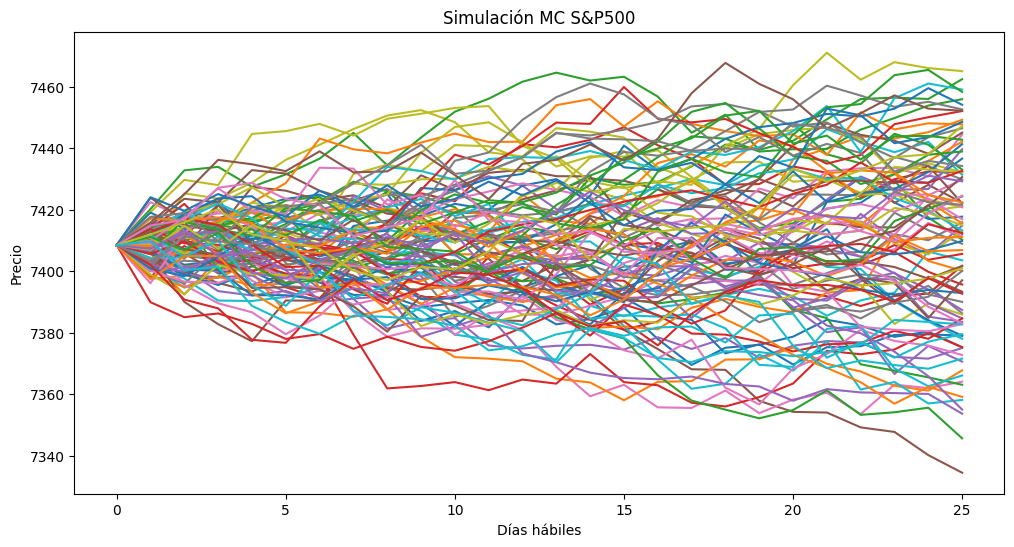

In [22]:
plt.figure(figsize=(12,6))
plt.plot(simulaciones[:, :100])
plt.title("Simulación MC S&P500")
plt.xlabel("Días hábiles")
plt.ylabel("Precio")
plt.show()

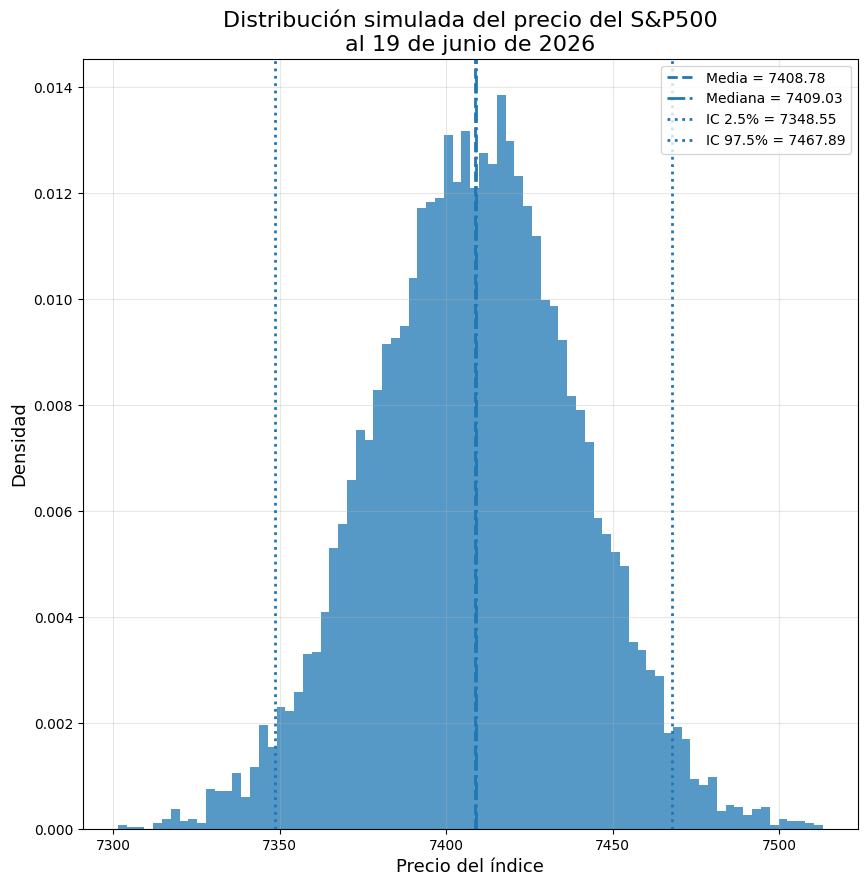

In [24]:
plt.figure(figsize=(10,10))
plt.hist(
    precio_final,
    bins=80,
    density=True,
    alpha=0.75)
# Línea media
plt.axvline(
    precio_esperado,
    linestyle="--",
    linewidth=2,
    label=f"Media = {precio_esperado:.2f}"
)
# Línea mediana
plt.axvline(
    precio_mediana,
    linestyle="-.",
    linewidth=2,
    label=f"Mediana = {precio_mediana:.2f}"
)
# Intervalo de confianza
plt.axvline(
    intervalo[0],
    linestyle=":",
    linewidth=2,
    label=f"IC 2.5% = {intervalo[0]:.2f}")
plt.axvline(
    intervalo[1],
    linestyle=":",
    linewidth=2,
    label=f"IC 97.5% = {intervalo[1]:.2f}")
plt.title(
    "Distribución simulada del precio del S&P500\nal 19 de junio de 2026",
    fontsize=16)
plt.xlabel("Precio del índice", fontsize=13)
plt.ylabel("Densidad", fontsize=13)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### <font color="lightseagreen"> **Predicción del precio esperado de Apple Inc.**

In [25]:
#Descargamos los datos
apple = "AAPL"
datos2 = yf.download(apple, start=inicio, end=fin)
precios2 = datos2["Close"]

/tmp/ipykernel_751/341016090.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos2 = yf.download(apple, start=inicio, end=fin)
[*********************100%***********************]  1 of 1 completed


<font color="darkturquoise">**Calculamos los rendimientos logarítmicos**

In [26]:
# Rendimientos logarítmicos
rendimientos2 = np.log(precios2 / precios2.shift(1))
rendimientos2 = rendimientos2.dropna()
media2 = rendimientos2.mean()
sigma2 = rendimientos2.std()
print(f"Rendimiento promedio diario: {media2.item():.6f}")
print(f"Volatilidad diaria: {sigma2.item():.6f}")

Rendimiento promedio diario: 0.000890
Volatilidad diaria: 0.019757


In [31]:
# Precio inicial
S02 = precios2.iloc[-1]
# Parámetros de simulación
n = 10000
dt = 1/252
# Matriz de simulaciones
simulaciones2 = np.zeros((T + 1, n))
# Condición inicial
simulaciones2[0] = S02
# Monte Carlo Apple
for t in range(1, T + 1):

    Z = np.random.standard_normal(n)

    simulaciones2[t] = simulaciones2[t-1] * np.exp(
        (media2.item() - 0.5 * sigma2.item()**2) * dt
        + sigma2.item() * np.sqrt(dt) * Z)
# Precios finales simulados
precio_final2 = simulaciones2[-1]
# Estadísticas
precio_esperado2 = np.mean(precio_final2)
precio_mediana2 = np.median(precio_final2)
intervalo2 = np.percentile(precio_final2, [2.5, 97.5])
# Resultados
print(f"Precio actual Apple: {S02}")

print(f"Precio esperado al 19/jun/2026: "
      f"{precio_esperado2:.2f}")

print(f"Precio mediano: "
      f"{precio_mediana2:.2f}")

print(f"Intervalo de confianza 95%: "
      f"[{intervalo2[0]:.2f}, {intervalo2[1]:.2f}]")

Precio actual Apple: Ticker
AAPL    300.230011
Name: 2026-05-15 00:00:00, dtype: float64
Precio esperado al 19/jun/2026: 300.24
Precio mediano: 300.23
Intervalo de confianza 95%: [296.56, 303.96]


<font color="darkturquoise"> **Conclusión:**


El precio estimado del cierre del Apple Inc. para el 19 de junio de 2026, utilizando simulación Monte Carlo con movimiento browniano geométrico, fue de 300.24 puntos, con un intervalo de confianza del 95% entre 296.56 y 303.96.

<font color="darkturquoise"> **Gráficos:**

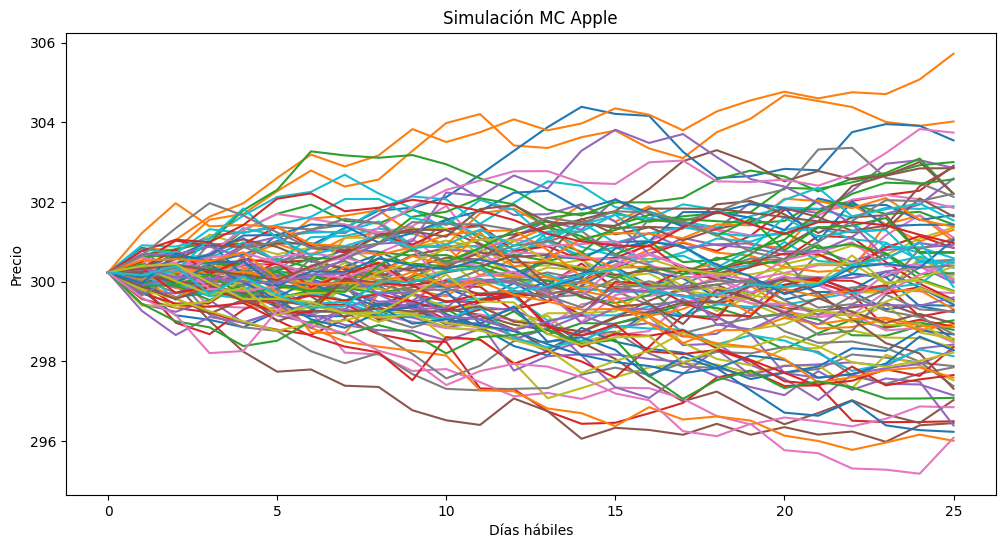

In [32]:
plt.figure(figsize=(12,6))
plt.plot(simulaciones2[:, :100])
plt.title("Simulación MC Apple")
plt.xlabel("Días hábiles")
plt.ylabel("Precio")
plt.show()

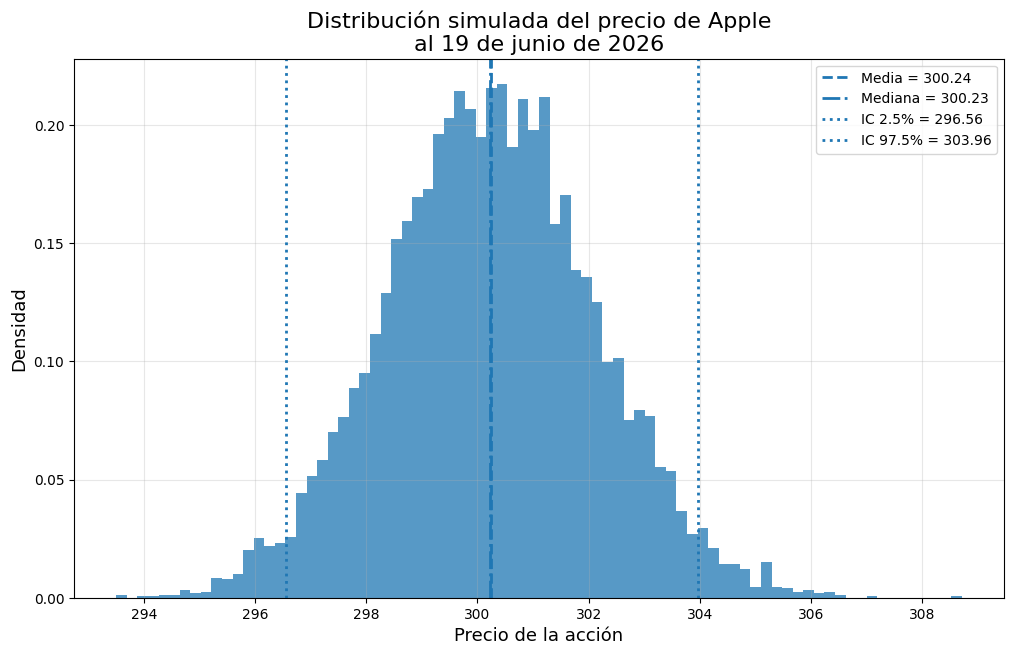

In [33]:
plt.figure(figsize=(12,7))
plt.hist(
    precio_final2,
    bins=80,
    density=True,
    alpha=0.75)
# Media
plt.axvline(
    precio_esperado2,
    linestyle="--",
    linewidth=2,
    label=f"Media = {precio_esperado2:.2f}")
# Mediana
plt.axvline(
    precio_mediana2,
    linestyle="-.",
    linewidth=2,
    label=f"Mediana = {precio_mediana2:.2f}")
# Intervalo de confianza
plt.axvline(
    intervalo2[0],
    linestyle=":",
    linewidth=2,
    label=f"IC 2.5% = {intervalo2[0]:.2f}")
plt.axvline(
    intervalo2[1],
    linestyle=":",
    linewidth=2,
    label=f"IC 97.5% = {intervalo2[1]:.2f}")

plt.title("Distribución simulada del precio de Apple\nal 19 de junio de 2026",
    fontsize=16)
plt.xlabel("Precio de la acción", fontsize=13)
plt.ylabel("Densidad", fontsize=13)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

<font color="darkmagenta">**Conclusión general:**

Mediante simulación Monte Carlo basada en movimiento browniano geométrico, se estimó el precio de cierre del S&P500 y de Apple para el 19 de junio de 2026. Los resultados muestran que Apple presenta una mayor volatilidad y dispersión en los precios simulados respecto al S&P500, debido a que una acción individual tiene mayor riesgo que un índice diversificado.